# OLMo Lineage Fingerprint Verification

Read a newer lineage verification JSON report, normalize each fingerprint technique into tidy tables, and plot success or closeness to the reference model across the configured lineage order.

In [13]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reuse this notebook with another newer lineage report by changing this path.
REPORT_PATH = Path("../artifacts/verification/olmo2_instruct_reference_trajectory.json")

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

## Load and Normalize

This notebook intentionally expects the newer lineage report shape from `scripts/verification/verify_fingerprint_lineage.py`: top-level `targets`, `target_metadata`, and per-technique results keyed by target keys such as `instruct@step_200`.

In [14]:
REQUIRED_LINEAGE_FIELDS = ("targets", "target_metadata")


def load_report(path: Path) -> dict:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Verification report not found: {path}")
    with path.open() as f:
        report = json.load(f)
    validate_new_lineage_report(report)
    return report


def validate_new_lineage_report(report: dict) -> None:
    missing = [field for field in REQUIRED_LINEAGE_FIELDS if field not in report]
    if missing:
        raise ValueError(
            "Expected newer lineage report schema; missing top-level field(s): "
            + ", ".join(missing)
        )
    if not isinstance(report["targets"], list) or not report["targets"]:
        raise ValueError("Expected report['targets'] to be a non-empty list")
    if not isinstance(report["target_metadata"], dict):
        raise ValueError("Expected report['target_metadata'] to be a mapping")
    missing_metadata = [key for key in report["targets"] if key not in report["target_metadata"]]
    if missing_metadata:
        raise ValueError(
            "Every target must have target_metadata; missing: "
            + ", ".join(missing_metadata)
        )


def target_display_label(row: pd.Series) -> str:
    label = str(row.get("label") or row["target_key"])
    revision = str(row.get("revision") or "main")
    step = row.get("step")
    if pd.notna(step):
        return f"{label}\n{revision}\nstep {int(step)}"
    if revision != "main":
        return f"{label}\n{revision}"
    return f"{label}\nmain"


def build_lineage_df(report: dict) -> pd.DataFrame:
    rows = []
    for order, target_key in enumerate(report["targets"]):
        metadata = dict(report["target_metadata"].get(target_key) or {})
        rows.append(
            {
                "target_key": target_key,
                "order": order,
                "label": metadata.get("label"),
                "model_id": metadata.get("model_id"),
                "revision": metadata.get("revision") or "main",
                "step": metadata.get("step"),
            }
        )
    lineage_df = pd.DataFrame(rows)
    lineage_df["display_label"] = lineage_df.apply(target_display_label, axis=1)
    return lineage_df


def _lineage_lookup(lineage_df: pd.DataFrame) -> pd.DataFrame:
    return lineage_df.set_index("target_key", drop=False)


def normalize_replay_results(report: dict, lineage_df: pd.DataFrame) -> pd.DataFrame:
    lineage_lookup = _lineage_lookup(lineage_df)
    rows = []
    for technique in report.get("fingerprint", []):
        if technique == "llmmap" or technique not in report:
            continue
        results = report.get(technique) or {}
        for target_key in report["targets"]:
            result = results.get(target_key)
            if not isinstance(result, dict) or "match_rate" not in result:
                continue
            lineage_row = lineage_lookup.loc[target_key].to_dict()
            rows.append(
                {
                    **lineage_row,
                    "technique": technique,
                    "matched": result.get("matched"),
                    "total": result.get("total"),
                    "match_rate": result.get("match_rate"),
                }
            )
    return pd.DataFrame(rows)


def normalize_llmmap_results(report: dict, lineage_df: pd.DataFrame) -> pd.DataFrame:
    lineage_lookup = _lineage_lookup(lineage_df)
    rows = []
    results = report.get("llmmap") or {}
    for target_key in report["targets"]:
        result = results.get(target_key)
        if not isinstance(result, dict):
            raise ValueError(f"Missing llmmap result for target {target_key!r}")
        if "matched_reference_top1" not in result:
            raise ValueError(
                f"LLMmap result for {target_key!r} is missing matched_reference_top1"
            )
        top_k = result.get("top_k") or []
        reference_model = result.get("reference_model") or report.get("reference_model")
        top1 = top_k[0] if top_k else {}
        reference_rank = None
        reference_distance = np.nan
        for index, item in enumerate(top_k, start=1):
            if item.get("label") == reference_model:
                reference_rank = index
                reference_distance = float(item.get("distance"))
                break
        if reference_rank is None:
            reference_rank_plot = len(top_k) + 1
            reference_rank_label = f">{len(top_k)}"
        else:
            reference_rank_plot = reference_rank
            reference_rank_label = str(reference_rank)
        lineage_row = lineage_lookup.loc[target_key].to_dict()
        rows.append(
            {
                **lineage_row,
                "technique": "llmmap",
                "matched_reference_top1": bool(result["matched_reference_top1"]),
                "reference_model": reference_model,
                "top1_label": top1.get("label"),
                "top1_distance": float(top1["distance"]) if "distance" in top1 else np.nan,
                "reference_rank_in_top_k": reference_rank,
                "reference_rank_plot": reference_rank_plot,
                "reference_rank_label": reference_rank_label,
                "reference_distance": reference_distance,
            }
        )
    return pd.DataFrame(rows)


def normalize_report(report: dict) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    validate_new_lineage_report(report)
    lineage_df = build_lineage_df(report)
    replay_df = normalize_replay_results(report, lineage_df)
    llmmap_df = normalize_llmmap_results(report, lineage_df)
    return lineage_df, replay_df, llmmap_df


In [15]:
try:
    report = load_report(REPORT_PATH)
    lineage_df, replay_df, llmmap_df = normalize_report(report)
    print(f"Loaded {REPORT_PATH}")
    print(f"Targets: {len(lineage_df)}")
    print(f"Replay rows: {len(replay_df)}")
    print(f"LLMmap rows: {len(llmmap_df)}")
except FileNotFoundError as exc:
    report = None
    lineage_df = pd.DataFrame()
    replay_df = pd.DataFrame()
    llmmap_df = pd.DataFrame()
    print(exc)
    print("Set REPORT_PATH to a newer lineage verification report, then rerun from this cell.")

Loaded ../artifacts/verification/olmo2_instruct_reference_trajectory.json
Targets: 31
Replay rows: 31
LLMmap rows: 31


## Replay Fingerprints

For replay-style fingerprints such as ProFLingo and TRAP, `match_rate` is the success rate against the reference fingerprint outputs.

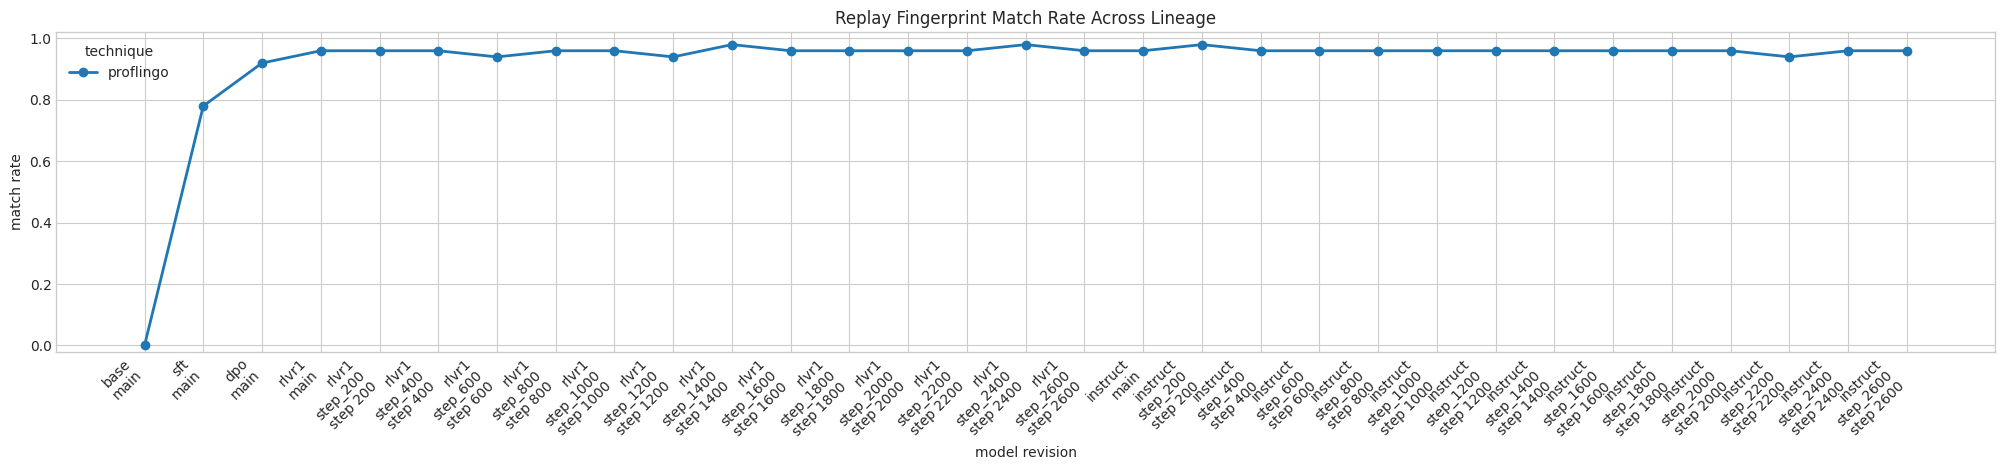

In [16]:
def plot_replay_match_rates(replay_df: pd.DataFrame, lineage_df: pd.DataFrame):
    if replay_df.empty:
        print("No replay-style fingerprint results found.")
        return None, None
    fig, ax = plt.subplots(figsize=(max(8, len(lineage_df) * 0.65), 4.8))
    for technique, group in replay_df.sort_values("order").groupby("technique", sort=False):
        ax.plot(
            group["order"],
            group["match_rate"],
            marker="o",
            linewidth=2,
            label=technique,
        )
    ax.set_title("Replay Fingerprint Match Rate Across Lineage")
    ax.set_ylabel("match rate")
    ax.set_xlabel("model revision")
    ax.set_ylim(-0.02, 1.02)
    ax.set_xticks(lineage_df["order"], lineage_df["display_label"], rotation=45, ha="right")
    ax.legend(title="technique")
    fig.tight_layout()
    return fig, ax


plot_replay_match_rates(replay_df, lineage_df);

## LLMmap Reference Closeness

LLMmap reports a nearest-template list. The plot uses the reference model's rank in `top_k`; if the reference is absent, it is plotted at `top_k + 1` and labeled as outside the returned candidates. Points marked with `x` are revisions where `matched_reference_top1` is false.

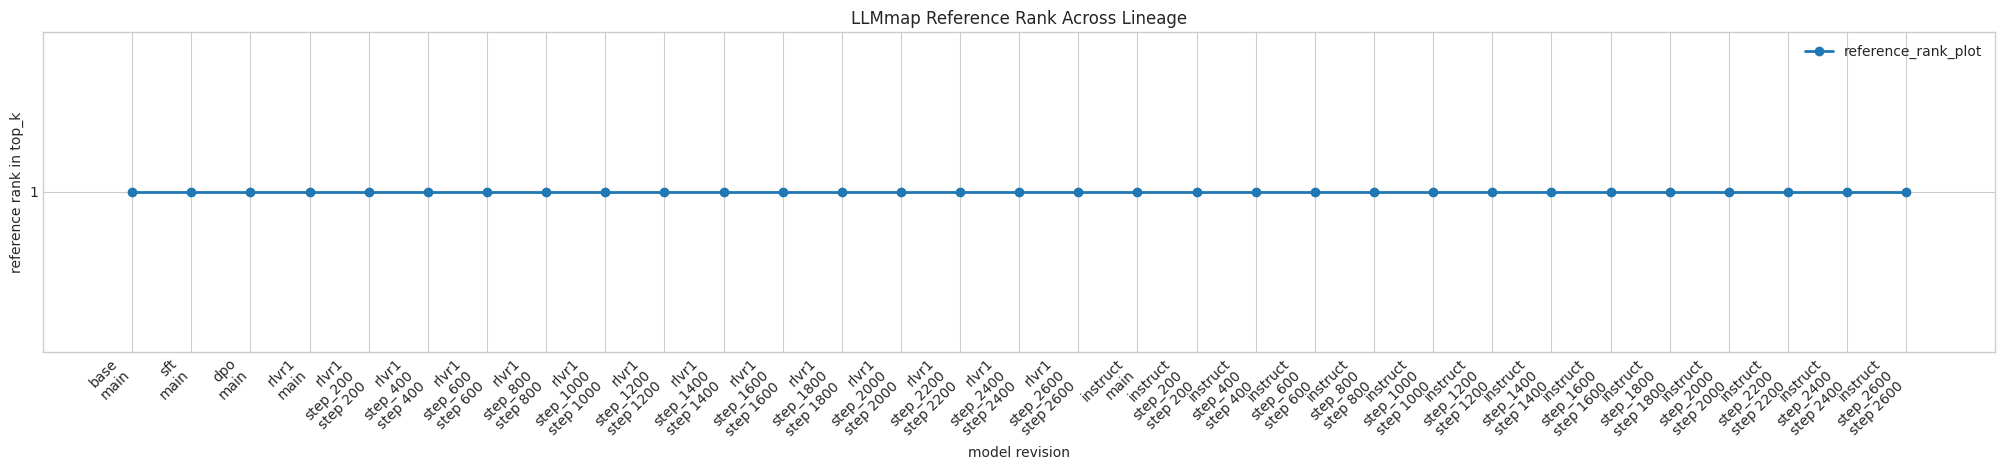

In [17]:
def plot_llmmap_reference_closeness(llmmap_df: pd.DataFrame, lineage_df: pd.DataFrame):
    if llmmap_df.empty:
        print("No LLMmap results found.")
        return None, None
    data = llmmap_df.sort_values("order")
    y_column = "reference_rank_plot"
    fig, ax = plt.subplots(figsize=(max(8, len(lineage_df) * 0.65), 4.8))
    ax.plot(data["order"], data[y_column], marker="o", linewidth=2, label=y_column)

    failures = data[data["matched_reference_top1"] == False]
    if not failures.empty:
        ax.scatter(
            failures["order"],
            failures[y_column],
            marker="x",
            s=90,
            linewidths=2.5,
            color="tab:red",
            label="top-1 not reference",
            zorder=3,
        )
    missing_count = int(data["reference_distance"].isna().sum())
    if missing_count:
        print(
            f"Reference model absent from top_k for {missing_count} target(s); "
            "rank is plotted at top_k + 1 for those points."
        )
    ax.set_title("LLMmap Reference Rank Across Lineage")
    ax.set_ylabel("reference rank in top_k")
    ax.set_xlabel("model revision")
    ax.invert_yaxis()
    ax.set_xticks(lineage_df["order"], lineage_df["display_label"], rotation=45, ha="right")
    ax.set_yticks(data[y_column].dropna().unique())
    ax.legend()
    fig.tight_layout()
    return fig, ax


plot_llmmap_reference_closeness(llmmap_df, lineage_df);

## Summary Tables

In [18]:
if not replay_df.empty:
    display(
        replay_df.sort_values(["technique", "order"])[
            ["technique", "target_key", "model_id", "revision", "step", "matched", "total", "match_rate"]
        ]
    )

if not llmmap_df.empty:
    display(
        llmmap_df.sort_values("order")[
            [
                "target_key",
                "model_id",
                "revision",
                "step",
                "matched_reference_top1",
                "top1_label",
                "top1_distance",
                "reference_rank_in_top_k",
                "reference_rank_label",
                "reference_distance",
            ]
        ]
    )

,technique,target_key,model_id,revision,step,matched,total,match_rate
0,proflingo,base@main,allenai/OLMo-2-0425-1B,main,NaN,0,50,0.00
1,proflingo,sft@main,allenai/OLMo-2-0425-1B-SFT,main,NaN,39,50,0.78
2,proflingo,dpo@main,allenai/OLMo-2-0425-1B-DPO,main,NaN,46,50,0.92
3,proflingo,rlvr1@main,allenai/OLMo-2-0425-1B-RLVR1,main,NaN,48,50,0.96
4,proflingo,rlvr1@step_200,allenai/OLMo-2-0425-1B-RLVR1,step_200,200.0,48,50,0.96
5,proflingo,rlvr1@step_400,allenai/OLMo-2-0425-1B-RLVR1,step_400,400.0,48,50,0.96
6,proflingo,rlvr1@step_600,allenai/OLMo-2-0425-1B-RLVR1,step_600,600.0,47,50,0.94
7,proflingo,rlvr1@step_800,allenai/OLMo-2-0425-1B-RLVR1,step_800,800.0,48,50,0.96
8,proflingo,rlvr1@step_1000,allenai/OLMo-2-0425-1B-RLVR1,step_1000,1000.0,48,50,0.96
9,proflingo,rlvr1@step_1200,allenai/OLMo-2-0425-1B-RLVR1,step_1200,1200.0,47,50,0.94


,target_key,model_id,revision,step,matched_reference_top1,top1_label,top1_distance,reference_rank_in_top_k,reference_rank_label,reference_distance
0,base@main,allenai/OLMo-2-0425-1B,main,NaN,True,allenai/OLMo-2-0425-1B-Instruct,29.375742,1,1,29.375742
1,sft@main,allenai/OLMo-2-0425-1B-SFT,main,NaN,True,allenai/OLMo-2-0425-1B-Instruct,19.466702,1,1,19.466702
2,dpo@main,allenai/OLMo-2-0425-1B-DPO,main,NaN,True,allenai/OLMo-2-0425-1B-Instruct,16.755659,1,1,16.755659
3,rlvr1@main,allenai/OLMo-2-0425-1B-RLVR1,main,NaN,True,allenai/OLMo-2-0425-1B-Instruct,13.353427,1,1,13.353427
4,rlvr1@step_200,allenai/OLMo-2-0425-1B-RLVR1,step_200,200.0,True,allenai/OLMo-2-0425-1B-Instruct,13.279953,1,1,13.279953
5,rlvr1@step_400,allenai/OLMo-2-0425-1B-RLVR1,step_400,400.0,True,allenai/OLMo-2-0425-1B-Instruct,15.546457,1,1,15.546457
6,rlvr1@step_600,allenai/OLMo-2-0425-1B-RLVR1,step_600,600.0,True,allenai/OLMo-2-0425-1B-Instruct,11.235123,1,1,11.235123
7,rlvr1@step_800,allenai/OLMo-2-0425-1B-RLVR1,step_800,800.0,True,allenai/OLMo-2-0425-1B-Instruct,14.251410,1,1,14.251410
8,rlvr1@step_1000,allenai/OLMo-2-0425-1B-RLVR1,step_1000,1000.0,True,allenai/OLMo-2-0425-1B-Instruct,13.874154,1,1,13.874154
9,rlvr1@step_1200,allenai/OLMo-2-0425-1B-RLVR1,step_1200,1200.0,True,allenai/OLMo-2-0425-1B-Instruct,11.756053,1,1,11.756053
